In [2]:
import numpy as np
import pandas as pd
import os
import math
import re
import random
import matplotlib.pyplot as plt



In [3]:
#collect data - metadata
data = []
data_dir = "20_newsgroups"
classes = os.listdir(data_dir)
for folder in classes:
    folder_path = f"{data_dir}/{folder}"
    if(os.path.exists(folder_path)):
        files = os.listdir(folder_path)
        print(len(files), folder_path)
        for file in files:
            file_path = f"{folder_path}/{file}"
            with open(file_path, "r", encoding="utf-8", errors="ignore" ) as f:
                text = f.read()
                data.append({"label": folder, "text": text})

1000 20_newsgroups/rec.motorcycles
1000 20_newsgroups/comp.sys.ibm.pc.hardware
1000 20_newsgroups/comp.windows.x
1000 20_newsgroups/comp.os.ms-windows.misc
1000 20_newsgroups/rec.sport.baseball
1000 20_newsgroups/sci.electronics
1000 20_newsgroups/misc.forsale
1000 20_newsgroups/sci.crypt
1000 20_newsgroups/comp.graphics
1000 20_newsgroups/sci.med
1000 20_newsgroups/alt.atheism
1000 20_newsgroups/talk.politics.guns
1000 20_newsgroups/sci.space
1000 20_newsgroups/talk.politics.misc
1000 20_newsgroups/talk.politics.mideast
1000 20_newsgroups/rec.autos
1000 20_newsgroups/rec.sport.hockey
997 20_newsgroups/soc.religion.christian
1000 20_newsgroups/comp.sys.mac.hardware
1000 20_newsgroups/talk.religion.misc


In [4]:
## feature engineering - clean data
def clean_text(data):
    if not data:
        return []
    data = data.lower()
    data = re.sub(r'[^\w\s]', ' ', data)
    data = re.sub(r'\d+', ' ', data)
    data = re.sub(r'\s+', ' ', data).strip()
    token = data.split()
    token = [t for t in token if len(t) > 2]
    return token

#Count terms frequency for each document
def term_frequency(data):
    dictionary = dict.fromkeys(set(data), 0)
    for token in data:
        dictionary[token] +=1
    return dictionary

for data_point in data:
    tokens = clean_text(data_point["text"])
    data_point["token_data"] = tokens
    data_point["term_freq_dict"] = term_frequency(tokens)


In [5]:
def fit(data,classes):
    vocab_global = set()
    class_word_counts = {}     
    class_word_freqs = {} 
    priors = {}                
    cond_probs = {}
    total_docs = len(data)

    for clas in classes:
        class_word_counts[clas] = 0
        class_word_freqs[clas] = {}
        priors[clas] = 0
    for d in data:
        class_label = d["label"]
        priors[class_label] += 1

        for term, freq in d["term_freq_dict"].items():
            class_word_freqs[class_label][term] = class_word_freqs[class_label].get(term, 0) + freq
            vocab_global.add(term)
            class_word_counts[class_label] += freq

    for clas in classes:
        priors[clas] = priors[clas] / total_docs

    total_vocab = len(vocab_global)

    for clas in classes:
        total_words_in_class = class_word_counts[clas]
        cond_probs[clas]={}
        for word in vocab_global:
            count_word_count = class_word_freqs[clas].get(word,0)
            cond_probs[clas][word] = (count_word_count + 1) / (total_words_in_class + total_vocab)

    return {
        "prior_probs": priors,
        "cond_probs": cond_probs,
        "vocabulary": vocab_global,
        "class_word_counts": class_word_counts
    }

In [6]:
def predict(doc, model):
    """
    Predict - P(Class)
    doc - dict {word: count}
    """
    priors = model["prior_probs"]
    cond_probs = model["cond_probs"]
    vocab = model["vocabulary"]

    probablity = {}

    for clas in priors:
        if priors[clas] <= 0:
            class_c = float("-inf")
        else:
            class_c = math.log(priors[clas])
        
        for word, count in doc.items():
            if word in vocab:
                prob_w_c = cond_probs[clas].get(word,0)
                if prob_w_c > 0:
                    class_c += count * math.log(prob_w_c)
        probablity[clas] = class_c

    prediction = max(probablity, key=probablity.get)
    return prediction, probablity

In [7]:
random.shuffle(data)

label_groups = {}
for d in data:
    label = d["label"]
    label_groups.setdefault(label, []).append(d)

train_data, test_data = [], []

for label, items in label_groups.items():
    n_total = len(items)
    n_test = int(n_total * 0.5)
    test_data.extend(items[:n_test])
    train_data.extend(items[n_test:])

In [8]:
model = fit(train_data, classes)

In [9]:
confusion_matrix = np.zeros((20,20),dtype=int)
total_accuracy = 0
for doc in test_data:
    prediction, prediction_classes = predict(doc["term_freq_dict"],model)
    i = classes.index(prediction)
    j = classes.index(doc["label"]) 
    confusion_matrix[i][j] +=1
    if (doc["label"] == prediction):
        total_accuracy+=1
print("Accuracy: ",total_accuracy / len(test_data))

Accuracy:  0.878875775155031


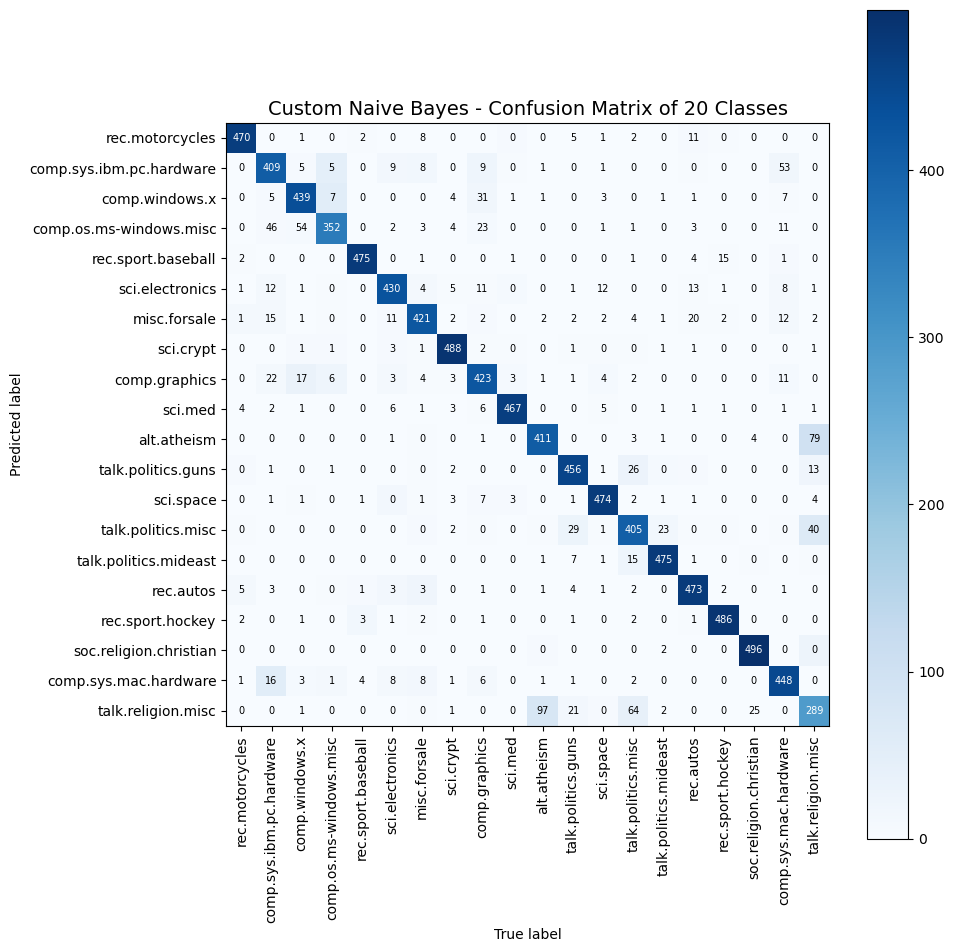

In [10]:
fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(confusion_matrix, interpolation='nearest', cmap='Blues')

ax.set_title("Custom Naive Bayes - Confusion Matrix of 20 Classes", fontsize=14)
fig.colorbar(im, ax=ax)

ax.set_xticks(np.arange(len(classes)))
ax.set_yticks(np.arange(len(classes)))
ax.set_xticklabels(classes, rotation=90)
ax.set_yticklabels(classes)

thresh = confusion_matrix.max() / 2.
for i in range(confusion_matrix.shape[0]):
    for j in range(confusion_matrix.shape[1]):
        ax.text(i, j, f"{confusion_matrix[i, j]:d}",
                ha="center", va="center",
                color="white" if confusion_matrix[i, j] > thresh else "black",
                fontsize=7)

ax.set_ylabel('Predicted label')
ax.set_xlabel('True label')
plt.tight_layout()
plt.show()